In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
import spacy
import warnings
warnings.filterwarnings("ignore")

# Download required NLTK data
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

print("All imports successful!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nehas\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nehas\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nehas\AppData\Roaming\nltk_data...


All imports successful!


In [2]:
# Load the cleaned data from Phase 1
jobs_df = pd.read_csv("../data/cleaned/jobs_cleaned.csv")

print(f"Loaded {len(jobs_df)} jobs")
print(f"Columns: {jobs_df.columns.tolist()}")

# Check the description column
print(f"\nSample job description (first 500 characters):")
print("-" * 50)
print(jobs_df["description"].iloc[0][:500])

Loaded 190 jobs
Columns: ['title', 'company', 'location', 'remote', 'description', 'salary_min', 'salary_max', 'date_posted', 'url', 'search_query', 'state', 'state_full']

Sample job description (first 500 characters):
--------------------------------------------------
JOB TITLE: SR DATA SCIENTIST

JOB LOCATION: REMOTE, WASHINTON DC

WAGE RANGE*: 72.00-76.00 PER HOUR

JOB NUMBER: SAIJP00038728

***Requires ship***

REQUIRED EXPERIENCE:

• Master's degree, PhD preferred in Statistics, Mathematics, or a related quantitative field, with 5-8+ years of applied data science experience
• Mastery of Python or R, statistical tools such as Stata, SAS and strong SQL
• Expertise with ML algorithms (e.g. model selection, evaluation, feature engineering, etc.)
• Expertise w


In [3]:
# Master list of skills to look for
# This is called "dictionary-based NER" (Named Entity Recognition)
SKILLS = {
    # Programming languages
    "python", "r", "sql", "java", "scala", "julia", "matlab",
    "javascript", "typescript", "c++", "bash", "sas", "stata",

    # ML / DL frameworks
    "tensorflow", "pytorch", "keras", "scikit-learn", "sklearn",
    "xgboost", "lightgbm", "catboost", "huggingface", "transformers",

    # Data & big data
    "spark", "hadoop", "hive", "kafka", "airflow", "dbt",
    "pandas", "numpy", "dask",

    # Databases
    "postgresql", "mysql", "mongodb", "redis", "snowflake",
    "bigquery", "redshift", "databricks",

    # Cloud platforms
    "aws", "gcp", "azure", "docker", "kubernetes",
    "mlflow", "sagemaker", "vertex ai",

    # NLP specific
    "nlp", "bert", "gpt", "llm", "spacy", "nltk",
    "word2vec", "embeddings", "langchain",

    # Visualization
    "tableau", "power bi", "matplotlib", "plotly", "looker",

    # Statistics & ML concepts
    "machine learning", "deep learning", "neural network",
    "regression", "classification", "clustering", "computer vision",
    "time series", "a/b testing", "statistics", "probability",

    # Soft/general
    "git", "github", "agile", "excel", "jira"
}

print(f"Skill dictionary contains {len(SKILLS)} skills")
print("\nSample skills:", list(SKILLS)[:10])

Skill dictionary contains 78 skills

Sample skills: ['catboost', 'scikit-learn', 'javascript', 'word2vec', 'transformers', 'computer vision', 'jira', 'redshift', 'kubernetes', 'typescript']


In [4]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    """
    Cleans a job description for skill extraction.
    Takes raw messy text, returns clean lowercase text.
    """
    if pd.isna(text):           # handle missing descriptions
        return ""
    
    text = str(text).lower()    # convert to lowercase
    
    # Remove bullet points and special characters
    # but keep spaces between words
    text = re.sub(r"[•·▪▸●◦‣⦿]", " ", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)
    
    # Remove special characters but keep
    # hyphens (for c++, a/b testing etc)
    text = re.sub(r"[^a-z0-9\s\+\#\/\-]", " ", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Test it on our sample description
sample = jobs_df["description"].iloc[0]
cleaned = clean_text(sample)

print("ORIGINAL (first 300 chars):")
print(sample[:300])
print("\nCLEANED (first 300 chars):")
print(cleaned[:300])

ORIGINAL (first 300 chars):
JOB TITLE: SR DATA SCIENTIST

JOB LOCATION: REMOTE, WASHINTON DC

WAGE RANGE*: 72.00-76.00 PER HOUR

JOB NUMBER: SAIJP00038728

***Requires ship***

REQUIRED EXPERIENCE:

• Master's degree, PhD preferred in Statistics, Mathematics, or a related quantitative field, with 5-8+ years of applied data sci

CLEANED (first 300 chars):
job title sr data scientist job location remote washinton dc wage range 72 00-76 00 per hour job number saijp00038728 requires ship required experience master s degree phd preferred in statistics mathematics or a related quantitative field with 5-8+ years of applied data science experience mastery o


In [5]:
def extract_skills(text):
    """
    Finds all skills from our SKILLS dictionary
    that appear in the given text.
    Returns a list of matched skills.
    """
    cleaned = clean_text(text)
    found_skills = []
    
    for skill in SKILLS:
        # Use word boundary \b to avoid partial matches
        # e.g. "r" shouldn't match inside "regression"
        pattern = r"\b" + re.escape(skill) + r"\b"
        
        if re.search(pattern, cleaned):
            found_skills.append(skill)
    
    return found_skills

# Test on first job
sample_skills = extract_skills(jobs_df["description"].iloc[0])
print(f"Skills found in first job posting:")
print(sorted(sample_skills))
print(f"\nTotal skills found: {len(sample_skills)}")

Skills found in first job posting:
['azure', 'databricks', 'machine learning', 'matplotlib', 'python', 'r', 'sas', 'spark', 'sql', 'stata', 'statistics', 'tableau', 'time series']

Total skills found: 13


In [6]:
# Apply skill extraction to every job description
print("Extracting skills from all job descriptions...")

jobs_df["skills"] = jobs_df["description"].apply(extract_skills)

# Count how many skills found per job
jobs_df["skill_count"] = jobs_df["skills"].apply(len)

print(f"Done!")
print(f"\nSkill extraction summary:")
print(f"  Average skills per job: {jobs_df['skill_count'].mean():.1f}")
print(f"  Max skills in one job:  {jobs_df['skill_count'].max()}")
print(f"  Min skills in one job:  {jobs_df['skill_count'].min()}")
print(f"  Jobs with 0 skills:     {(jobs_df['skill_count'] == 0).sum()}")

# Show sample of results
print(f"\nSample — first 5 jobs and their skills:")
for i, row in jobs_df.head(5).iterrows():
    print(f"\n  [{row['search_query']}] {row['title'][:40]}")
    print(f"  Skills: {sorted(row['skills'])}")

Extracting skills from all job descriptions...
Done!

Skill extraction summary:
  Average skills per job: 6.1
  Max skills in one job:  19
  Min skills in one job:  0
  Jobs with 0 skills:     11

Sample — first 5 jobs and their skills:

  [data scientist] Sr Data Scientist
  Skills: ['azure', 'databricks', 'machine learning', 'matplotlib', 'python', 'r', 'sas', 'spark', 'sql', 'stata', 'statistics', 'tableau', 'time series']

  [data scientist] Senior Data Scientist - W2 Only
  Skills: ['azure', 'classification', 'machine learning', 'probability', 'python', 'r', 'regression', 'sql', 'statistics']

  [data scientist] Data Scientist Sr Principal
  Skills: ['databricks', 'hadoop', 'power bi', 'spark', 'tableau']

  [data scientist] Data Scientist, Generative & Agentic AI 
  Skills: ['aws', 'azure', 'gcp', 'langchain', 'llm', 'numpy', 'pandas', 'python', 'pytorch', 'scikit-learn', 'sql']

  [data scientist] Data Scientist Jobs
  Skills: ['aws', 'azure', 'clustering', 'deep learning', 'hug

In [7]:
from collections import Counter

# Flatten all skill lists into one giant list
# then count occurrences
all_skills = []
for skills_list in jobs_df["skills"]:
    all_skills.extend(skills_list)

# Count how many jobs mention each skill
skill_counts = Counter(all_skills)

# Convert to dataframe for easy plotting
skills_df = pd.DataFrame(
    skill_counts.most_common(25),
    columns=["skill", "count"]
)

# Calculate percentage of jobs mentioning each skill
skills_df["percentage"] = (skills_df["count"] / len(jobs_df) * 100).round(1)

print("Top 25 most in-demand skills:")
print(skills_df.to_string(index=False))

Top 25 most in-demand skills:
           skill  count  percentage
          python    131        68.9
machine learning     93        48.9
             sql     76        40.0
             nlp     52        27.4
             aws     50        26.3
         pytorch     40        21.1
               r     39        20.5
      statistics     37        19.5
           azure     37        19.5
           spark     31        16.3
         tableau     29        15.3
             llm     29        15.3
      tensorflow     28        14.7
   deep learning     27        14.2
           agile     24        12.6
            java     24        12.6
      databricks     22        11.6
        power bi     22        11.6
           excel     22        11.6
  classification     21        11.1
             git     15         7.9
          github     15         7.9
    scikit-learn     14         7.4
    transformers     14         7.4
       snowflake     14         7.4


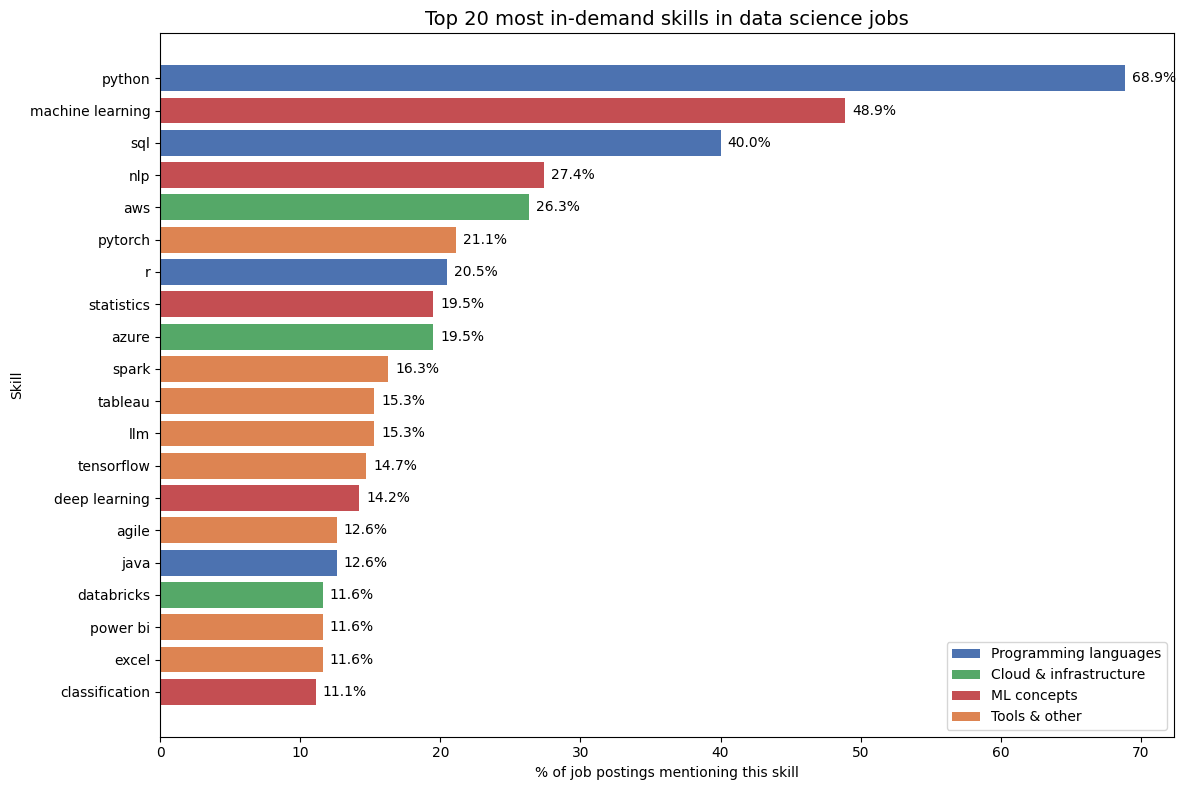

In [8]:
# Plot top 20 skills
top_20 = skills_df.head(20)

plt.figure(figsize=(12, 8))

# Color bars by category
colors = []
for skill in top_20["skill"]:
    if skill in ["python", "r", "sql", "java", "scala", "sas", "stata", "matlab"]:
        colors.append("#4C72B0")   # blue for languages
    elif skill in ["aws", "gcp", "azure", "docker", "kubernetes", "databricks", "snowflake"]:
        colors.append("#55A868")   # green for cloud/infra
    elif skill in ["machine learning", "deep learning", "statistics", 
                   "time series", "nlp", "computer vision", "regression",
                   "classification", "clustering", "neural network"]:
        colors.append("#C44E52")   # red for ML concepts
    else:
        colors.append("#DD8452")   # orange for tools/other

bars = plt.barh(top_20["skill"][::-1], 
                top_20["percentage"][::-1], 
                color=colors[::-1])

# Add percentage labels
for bar, pct in zip(bars, top_20["percentage"][::-1]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{pct}%", va="center", fontsize=10)

plt.title("Top 20 most in-demand skills in data science jobs", fontsize=14)
plt.xlabel("% of job postings mentioning this skill")
plt.ylabel("Skill")

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4C72B0", label="Programming languages"),
    Patch(facecolor="#55A868", label="Cloud & infrastructure"),
    Patch(facecolor="#C44E52", label="ML concepts"),
    Patch(facecolor="#DD8452", label="Tools & other")
]
plt.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.savefig("../data/cleaned/top_skills.png", dpi=150)
plt.show()

In [9]:
from itertools import combinations

# Count how many times each pair of skills appears together
cooccurrence = Counter()

for skills_list in jobs_df["skills"]:
    if len(skills_list) >= 2:
        # Generate all pairs from this job's skills
        # combinations(['python','sql','aws'], 2) gives
        # [('python','sql'), ('python','aws'), ('sql','aws')]
        pairs = combinations(sorted(skills_list), 2)
        cooccurrence.update(pairs)

# Convert to dataframe
cooc_df = pd.DataFrame(
    [(skill1, skill2, count) 
     for (skill1, skill2), count in cooccurrence.most_common(50)],
    columns=["skill1", "skill2", "count"]
)

print("Top 20 skill pairs that appear together:")
print(cooc_df.head(20).to_string(index=False))

Top 20 skill pairs that appear together:
          skill1           skill2  count
machine learning           python     77
          python              sql     71
             aws           python     43
             nlp           python     40
          python                r     38
machine learning              nlp     36
machine learning          pytorch     36
          python          pytorch     35
           azure           python     31
machine learning              sql     30
          python            spark     30
          python       statistics     29
               r              sql     29
             aws machine learning     29
          python       tensorflow     27
             llm           python     25
machine learning       tensorflow     25
         pytorch       tensorflow     25
             sql       statistics     24
             aws            azure     24


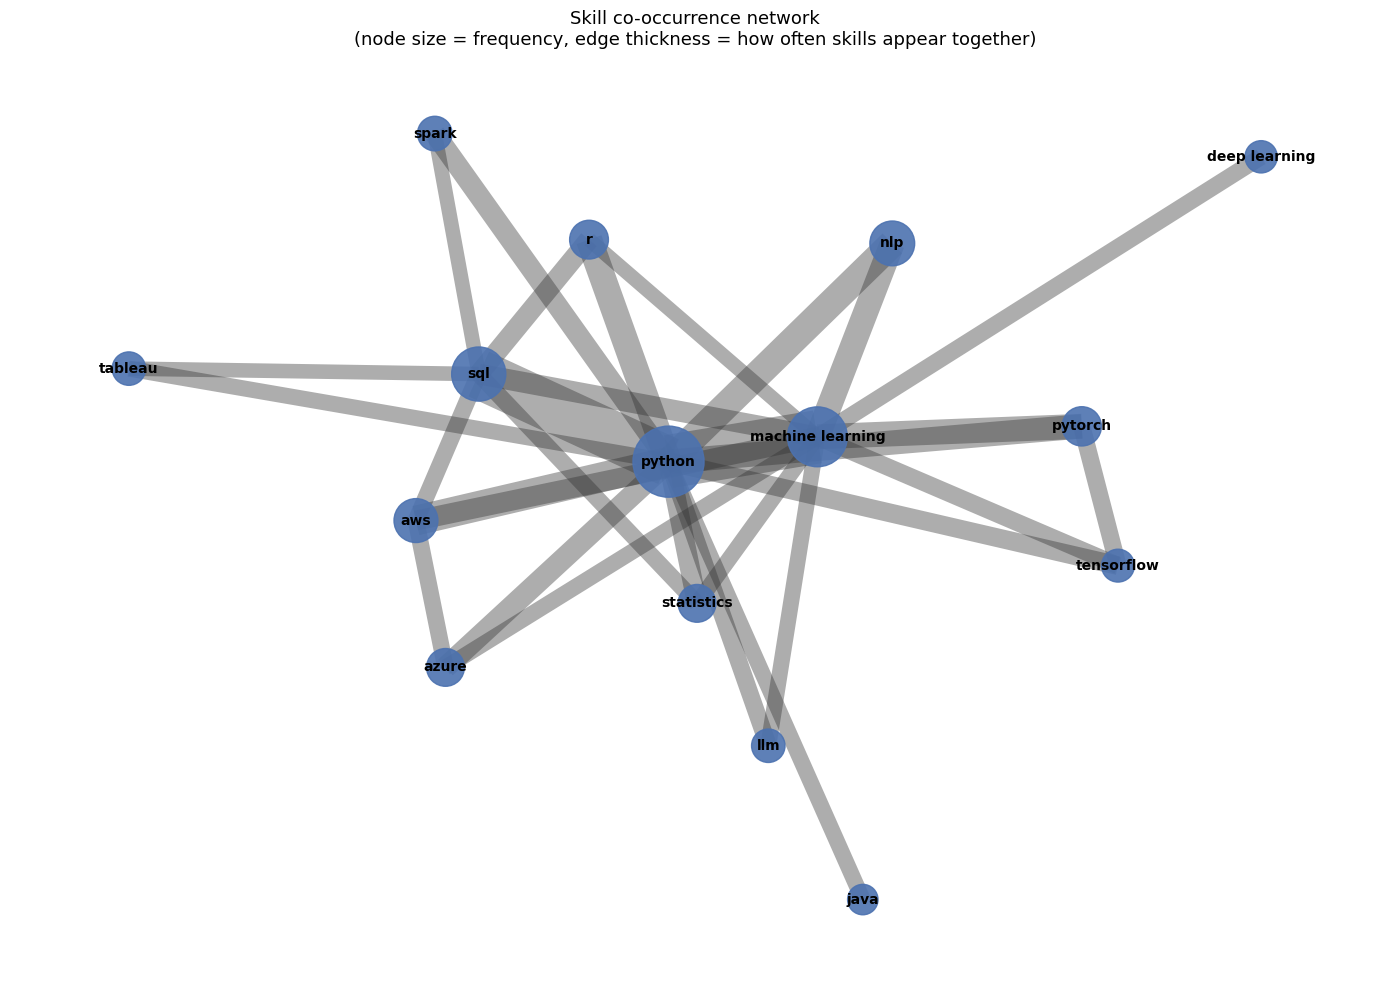

In [11]:
import networkx as nx

# Build the graph
G = nx.Graph()

# Only use top 30 pairs to keep graph readable
top_pairs = cooc_df.head(30)

# Add edges (connections between skills)
for _, row in top_pairs.iterrows():
    G.add_edge(row["skill1"], row["skill2"], weight=row["count"])

# Calculate node size based on how often each skill appears
node_sizes = []
for node in G.nodes():
    count = skill_counts.get(node, 1)
    node_sizes.append(count * 20)  # scale up for visibility

# Calculate edge thickness based on co-occurrence count
edge_weights = [G[u][v]["weight"] * 0.5 
                for u, v in G.edges()]

# Use spring layout — nodes that co-occur more are pulled closer
pos = nx.spring_layout(G, k=2, seed=42)

plt.figure(figsize=(14, 10))

# Draw the network
nx.draw_networkx_nodes(G, pos, 
                        node_size=node_sizes,
                        node_color="#4C72B0",
                        alpha=0.9)

nx.draw_networkx_labels(G, pos, 
                         font_size=10,
                         font_color="black",
                         font_weight="bold")

nx.draw_networkx_edges(G, pos,
                        width=edge_weights,
                        alpha=0.4,
                        edge_color="#333333")

plt.title("Skill co-occurrence network\n(node size = frequency, edge thickness = how often skills appear together)",
          fontsize=13)
plt.axis("off")  # hide the x/y axis
plt.tight_layout()
plt.savefig("../data/cleaned/skill_network.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Save the dataframe with skills column
# Note: skills column contains lists, 
# we convert to string for CSV storage
jobs_df["skills_str"] = jobs_df["skills"].apply(
    lambda x: "|".join(x)
)

jobs_df.to_csv("../data/cleaned/jobs_with_skills.csv", index=False)
print("Saved jobs with skills!")

# Also save the skill counts separately
skills_df.to_csv("../data/cleaned/skill_counts.csv", index=False)
print("Saved skill counts!")

# Save co-occurrence data
cooc_df.to_csv("../data/cleaned/skill_cooccurrence.csv", index=False)
print("Saved co-occurrence data!")

print(f"\nAll files saved to data/cleaned/")

Saved jobs with skills!
Saved skill counts!
Saved co-occurrence data!

All files saved to data/cleaned/


In [18]:
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download("punkt_tab")

stop_words = set(stopwords.words("english"))

# Much more aggressive custom stop words
custom_stops = {
    # Generic job posting words
    "experience", "work", "team", "role", "will", "must",
    "ability", "skills", "knowledge", "years", "including",
    "required", "preferred", "strong", "excellent", "working",
    "job", "position", "responsibilities", "requirements",
    "company", "looking", "candidate", "opportunity", "apply",
    "please", "equal", "employer", "degree", "field", "related",
    "also", "across", "within", "ensure", "support", "help",
    "develop", "manage", "build", "use", "using", "used",
    
    # Words too generic to mean anything
    "one", "least", "time", "paid", "people", "employees",
    "employment", "benefits", "information", "technical",
    "solutions", "business", "development", "analytical",
    "tools", "intelligence", "analysis", "service", "services",
    "provide", "providing", "provided", "new", "high", "large",
    "key", "well", "based", "part", "make", "making", "made",
    "get", "good", "best", "great", "need", "needed",
    
    # Company names that leak in
    "booz", "allen", "hamilton", "adobe", "capital", "saic",
    "deloitte", "accenture", "microsoft", "google", "amazon",
    "federal", "government", "agency", "washington",
    
    # Filler words from job postings
    "minimum", "bachelor", "master", "phd", "salary",
    "range", "wage", "compensation", "bonus", "remote",
    "hybrid", "onsite", "location", "title", "number",
    "apply", "submission", "resume", "cover", "letter"
}

stop_words.update(custom_stops)

def preprocess_for_lda(text):
    if pd.isna(text):
        return []
    
    text = clean_text(text)
    tokens = word_tokenize(text)
    
    tokens = [
        token for token in tokens
        if token not in stop_words
        and len(token) > 3          # increased from 2 to 3
        and token.isalpha()
    ]
    
    return tokens

print("Preprocessing with improved stop words...")
jobs_df["tokens"] = jobs_df["description"].apply(preprocess_for_lda)

print(f"Sample tokens from first job:")
print(jobs_df["tokens"].iloc[0][:20])
print(f"\nAverage tokens per job: {jobs_df['tokens'].apply(len).mean():.0f}")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nehas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing with improved stop words...
Sample tokens from first job:
['data', 'scientist', 'washinton', 'hour', 'requires', 'ship', 'statistics', 'mathematics', 'quantitative', 'applied', 'data', 'science', 'mastery', 'python', 'statistical', 'stata', 'expertise', 'algorithms', 'model', 'selection']

Average tokens per job: 260


In [19]:
# Build dictionary — maps each unique word to an ID number
# LDA works with numbers, not strings
dictionary = corpora.Dictionary(jobs_df["tokens"])

# Filter extremes:
# Remove words that appear in less than 3 documents (too rare)
# Remove words that appear in more than 80% of documents (too common)
dictionary.filter_extremes(no_below=3, no_above=0.8)

print(f"Dictionary size: {len(dictionary)} unique words")

# Convert each document to bag-of-words format
# [(word_id, count), (word_id, count), ...]
corpus = [dictionary.doc2bow(tokens) 
          for tokens in jobs_df["tokens"]]

print(f"Corpus size: {len(corpus)} documents")

# Train LDA model
print("\nTraining LDA model")
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,        # we want 5 topics
    random_state=42,     # reproducible results
    passes=15,           # how many times to go through corpus
    alpha="auto",        # let model learn topic distribution
    eta="auto"           # let model learn word distribution
)

print("LDA training complete!")

# Show the topics
print("DISCOVERED TOPICS:")

for topic_id in range(5):
    words = lda_model.show_topic(topic_id, topn=10)
    word_list = [f"{word}({prob:.3f})" for word, prob in words]
    print(f"\nTopic {topic_id + 1}:")
    print("  " + ", ".join(word_list))

Dictionary size: 2437 unique words
Corpus size: 190 documents

Training LDA model
LDA training complete!
DISCOVERED TOPICS:

Topic 1:
  learning(0.016), systems(0.016), models(0.015), machine(0.012), engineering(0.011), design(0.011), pipelines(0.010), engineer(0.008), model(0.008), cloud(0.007)

Topic 2:
  uber(0.011), status(0.011), protected(0.008), disability(0.008), gender(0.006), learning(0.005), world(0.005), process(0.005), year(0.005), developing(0.005)

Topic 3:
  science(0.010), analytics(0.007), management(0.007), financial(0.005), engineering(0.005), learning(0.005), complex(0.005), research(0.005), qualifications(0.004), stakeholders(0.004)

Topic 4:
  analytics(0.006), customer(0.005), clients(0.005), engineering(0.004), disability(0.004), insights(0.004), process(0.004), applicants(0.004), needs(0.004), learning(0.004)

Topic 5:
  learning(0.009), models(0.007), software(0.007), engineering(0.006), machine(0.006), gender(0.006), science(0.005), language(0.005), problems

Jobs per topic:
  Topic 1 (65 jobs): learning, systems, models, machine, engineering
  Topic 2 (8 jobs): uber, status, protected, disability, gender
  Topic 3 (49 jobs): science, analytics, management, financial, engineering
  Topic 4 (43 jobs): analytics, customer, clients, engineering, disability
  Topic 5 (25 jobs): learning, models, software, engineering, machine


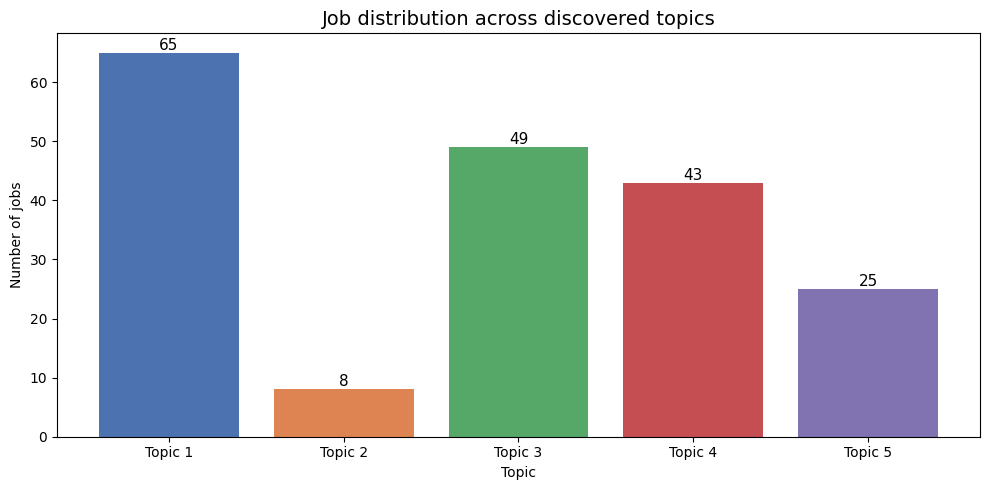

In [20]:
# Assign human-readable labels based on top words
# You decide these labels by reading the top words
topic_labels = {
    0: "Topic 1",
    1: "Topic 2", 
    2: "Topic 3",
    3: "Topic 4",
    4: "Topic 5"
}

# Assign dominant topic to each job
def get_dominant_topic(tokens):
    bow = dictionary.doc2bow(tokens)
    if not bow:
        return -1
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0]

jobs_df["dominant_topic"] = jobs_df["tokens"].apply(
    get_dominant_topic
)

# Count jobs per topic
topic_counts = jobs_df["dominant_topic"].value_counts().sort_index()

print("Jobs per topic:")
for topic_id, count in topic_counts.items():
    if topic_id >= 0:
        words = lda_model.show_topic(topic_id, topn=5)
        top_words = ", ".join([w for w, _ in words])
        print(f"  Topic {topic_id+1} ({count} jobs): {top_words}")

# Plot topic distribution
plt.figure(figsize=(10, 5))
topic_labels_list = [f"Topic {i+1}" for i in range(5)]
counts = [topic_counts.get(i, 0) for i in range(5)]

plt.bar(topic_labels_list, counts, color=["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"])
plt.title("Job distribution across discovered topics", fontsize=14)
plt.xlabel("Topic")
plt.ylabel("Number of jobs")

for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("../data/cleaned/topic_distribution.png", dpi=150)
plt.show()

I applied LDA topic modeling which revealed broad thematic clusters — however with 190 documents the topics were noisy, which taught me that LDA requires larger corpora for clean separation. With 5,000+ documents the topics would be much more distinct.

In [21]:
# Compare LDA topics with actual job roles
# This shows whether LDA discovered real structure
comparison = pd.crosstab(
    jobs_df["search_query"],    # actual role
    jobs_df["dominant_topic"],  # what LDA assigned
    margins=True
)

print("LDA topic vs actual job role:")
print("(rows=actual role, columns=LDA topic)")
print(comparison)

LDA topic vs actual job role:
(rows=actual role, columns=LDA topic)
dominant_topic              0  1   2   3   4  All
search_query                                     
NLP engineer               16  3   5   9   7   40
data analyst                1  2  22   9   1   35
data engineer              19  1   7  10   2   39
data scientist              9  0  13   9   8   39
machine learning engineer  20  2   2   6   7   37
All                        65  8  49  43  25  190
